# TECH CHALLENGE - FASE 1
**Case E-commerce Olist**

# 1. Objetivo

Este desafio tem como objetivo criar um relatório executivo voltado a
investidores e acionistas do setor de e-commerce, baseado no Brazilian E-Commerce Public Dataset by Olist.


# 2. Carregamento dos Dados

In [2]:
# Importação das Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Carregamento dos dados
df_pedidos = pd.read_csv('/content/pedidos_clientes.csv', index_col=0)
df_regional = pd.read_csv('/content/analise_regional.csv', index_col=0)



In [4]:
df_pedidos.head()

,customer_unique,customer_city,customer_state,order_id,customer_id:1,order_status,order_purchase_t,order_approved_a,order_delivered_6,order_estimated
customer_id,,,,,,,,,,
9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18 00:00:00
b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13 00:00:00
41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04 00:00:00
f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15 00:00:00
8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26 00:00:00


In [61]:
df_regional.head()

,order_item_id,seller_id,price,freight_value,customer_id,order_status,customer_unique,customer_city,customer_state,seller_city,seller_state,frete_por_preco
order_id,,,,,,,,,,,,
00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,volta redonda,SP,0.225637
00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,sao paulo,SP,0.083076
000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,borda da mata,MG,0.089799
00024acbcdf0a6daa1e931b038114c75,1,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,franca,SP,0.984604
00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,loanda,PR,0.090745


Foram utilizados dois arquivos CSV derivados do dataset original Brazilian E-Commerce Public Dataset by Olist, previamente estruturados em SQL para atender aos objetivos da análise.

O primeiro arquivo (pedidos_clientes.csv) concentra informações relacionadas aos pedidos, clientes, localização e indicadores de prazo de entrega. O segundo (analise_regional.csv) contém informações relacionadas aos itens dos pedidos, vendedores, localização de clientes e vendedores, prazos de entrega, preço dos produtos e valor do frete.

A principal diferença entre os dois arquivos está na granularidade, ou nível de observação de cada uma. A tabela pedidos_clientes apresenta uma visão orientada ao pedido e ao cliente, sendo utilizada principalmente para análises de demanda, distribuição geográfica dos consumidores, evolução temporal e desempenho das entregas. Já a tabela analise_regional apresenta uma granularidade mais detalhada, no nível dos itens dos pedidos, permitindo incorporar informações de vendedores, produtos, preços e frete.

# 3. Inspeção e Preparação dos Dados

In [67]:
# Verificação dos dtypes de cada coluna em df_pedidos
df_pedidos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99441 entries, 9ef432eb6251297304e76186b10a928d to edb027a75a1449115f6b43211ae02a24
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_unique       99441 non-null  object        
 1   customer_city         99441 non-null  object        
 2   customer_state        99441 non-null  object        
 3   order_id              99441 non-null  object        
 4   customer_id:1         99441 non-null  object        
 5   order_status          99441 non-null  object        
 6   order_purchase_t      99441 non-null  datetime64[ns]
 7   order_approved_a      99281 non-null  datetime64[ns]
 8   order_delivered_6     96476 non-null  datetime64[ns]
 9   order_estimated       99441 non-null  datetime64[ns]
 10  tempo_entrega_total   96462 non-null  float64       
 11  tempo_estimado_total  99281 non-null  float64       
 12  tempo_entrega_atraso 

In [7]:
# Passar as colunas de datas para datetime
df_pedidos['order_purchase_t'] = pd.to_datetime(df_pedidos['order_purchase_t'])
df_pedidos['order_approved_a'] = pd.to_datetime(df_pedidos['order_approved_a'])
df_pedidos['order_delivered_6'] = pd.to_datetime(df_pedidos['order_delivered_6'])
df_pedidos['order_estimated'] = pd.to_datetime(df_pedidos['order_estimated'])


In [8]:
# Calcular e criar nova coluna com o tempo de entrega total
df_pedidos['tempo_entrega_total'] = df_pedidos['order_delivered_6'] - df_pedidos['order_approved_a']
df_pedidos['tempo_entrega_total'] = df_pedidos['tempo_entrega_total'].dt.days

In [9]:
# Calcular e criar nova coluna com o tempo estimado total
df_pedidos['tempo_estimado_total'] = df_pedidos['order_estimated'] - df_pedidos['order_approved_a']
df_pedidos['tempo_estimado_total'] = df_pedidos['tempo_estimado_total'].dt.days

In [10]:
# Calcular e criar nova coluna com o tempo de atraso, se houver
df_pedidos['tempo_entrega_atraso'] = np.where(df_pedidos['tempo_entrega_total'] > df_pedidos['tempo_estimado_total'], 1, 0)



In [11]:
# Criar nova coluna com o Ano do pedido
df_pedidos['ano'] = df_pedidos['order_purchase_t'].dt.year
sorted(df_pedidos['order_purchase_t'].dt.year.unique())

[np.int32(2016), np.int32(2017), np.int32(2018)]

In [12]:
df_pedidos.head()

,customer_unique,customer_city,customer_state,order_id,customer_id:1,order_status,order_purchase_t,order_approved_a,order_delivered_6,order_estimated,tempo_entrega_total,tempo_estimado_total,tempo_entrega_atraso,ano
customer_id,,,,,,,,,,,,,,
9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,8.0,15.0,0,2017
b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,12.0,17.0,0,2018
41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,9.0,26.0,0,2018
f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15,13.0,26.0,0,2017
8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26,2.0,12.0,0,2018


In [13]:
# Verificar quantidade de clientes únicos
df_pedidos['customer_unique'].nunique()


96096

In [71]:
# verificar número total de pedidos
df_pedidos['order_id'].count()

np.int64(99441)

In [65]:
# Verificar se a quantidade de id de clientes batem com número total de pedidos
df_pedidos['customer_id:1'].nunique()


99441

In [15]:
df_pedidos.columns

Index(['customer_unique', 'customer_city', 'customer_state', 'order_id',
       'customer_id:1', 'order_status', 'order_purchase_t', 'order_approved_a',
       'order_delivered_6', 'order_estimated', 'tempo_entrega_total',
       'tempo_estimado_total', 'tempo_entrega_atraso', 'ano'],
      dtype='object')

In [63]:
# Verificação dos dtypes de cada coluna em df_regional
df_regional.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112650 entries, 00010242fe8c5a6d1ba2dd792cb16214 to fffe41c64501cc87c801fd61db3f6244
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_item_id    112650 non-null  int64  
 1   seller_id        112650 non-null  object 
 2   price            112650 non-null  float64
 3   freight_value    112650 non-null  float64
 4   customer_id      112650 non-null  object 
 5   order_status     112650 non-null  object 
 6   customer_unique  112650 non-null  object 
 7   customer_city    112650 non-null  object 
 8   customer_state   112650 non-null  object 
 9   seller_city      112650 non-null  object 
 10  seller_state     112650 non-null  object 
 11  frete_por_preco  112650 non-null  float64
dtypes: float64(3), int64(1), object(8)
memory usage: 15.2+ MB


In [62]:
df_regional.columns.tolist()

['order_item_id',
 'seller_id',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'customer_unique',
 'customer_city',
 'customer_state',
 'seller_city',
 'seller_state',
 'frete_por_preco']

Inicialmente, foi realizada uma inspeção da estrutura dos DataFrames, utilizando métodos como info(), columns e columns.tolist(), com o objetivo de verificar as variáveis disponíveis, compreender a estrutura das tabelas e identificar possíveis inconsistências nos dados.

Foi identificado que as colunas 'order_purchase_t', 'order_approved_a','order_delivered_6', 'order_estimated' estavam com dtype object o que dificultaria a aplicação de fórmulas matemáticas. Isso pôde ser corrigido através da aplicação do pd.datetime() e foram criadas novas colunas com o cálculo do tempo de entrega estimado, tempo total e atraso, em dias. Também foi criada uma nova coluna com o Ano do pedido.

Também foi realizada uma análise dos identificadores de clientes. Foram comparadas as variáveis customer_unique e customer_id:1, verificando-se a quantidade de valores únicos de cada uma. A variável customer_unique apresentou 96.096 identificadores únicos, enquanto customer_id:1 apresentou 99.441, indicando que as variáveis não deveriam ser tratadas como equivalentes.

# 4. Análise Exploratória (EDA)

A análise exploratória dos dados (EDA) foi realizada com o objetivo de identificar padrões, distribuições e características relevantes do conjunto de dados antes da construção dos indicadores regionais.

Indicadores a serem analisados na EDA:

Volume de pedidos por Estado;

Top 5 Estados com maior volume de vendas;

Evolução de vendas ao longo dos anos;

Análise da Receita por Estado;

Ticket médio por Estado;

Frete médio e impacto do valor do frete sobre o produto;

Concentração de vendedores por Estado;

Relação entre concentração de clientes x concentração de vendedores.

In [17]:
# Verificar qual Estado tem o maior número de pedidos e ordenar do maior para o menor
pedidos_por_estado = (
    df_pedidos
    .groupby(['customer_state'])['order_id']
    .nunique()
    .reset_index(name='total_pedidos')
    .sort_values('total_pedidos', ascending=False)
    .reset_index(drop=True)
)
pedidos_por_estado

,customer_state,total_pedidos
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [76]:
media_pedidos = pedidos_por_estado['total_pedidos'].mean()

mediana_pedidos = pedidos_por_estado['total_pedidos'].median()

print(f'Média: {media_pedidos:.2f}')
print(f'Mediana: {mediana_pedidos:.2f}')

Média: 3683.00
Mediana: 907.00


São Paulo tem o maior número total de pedidos com 41746, enquanto Roraima tem o menor número com 46 pedidos registrados. A média é de 3683 pedidos por Estado e a mediana é de 907 por Estado, o que mostra que SP é um grande outlier do nosso Dataset. Roraima também pode ser um outlier no limite inferior.

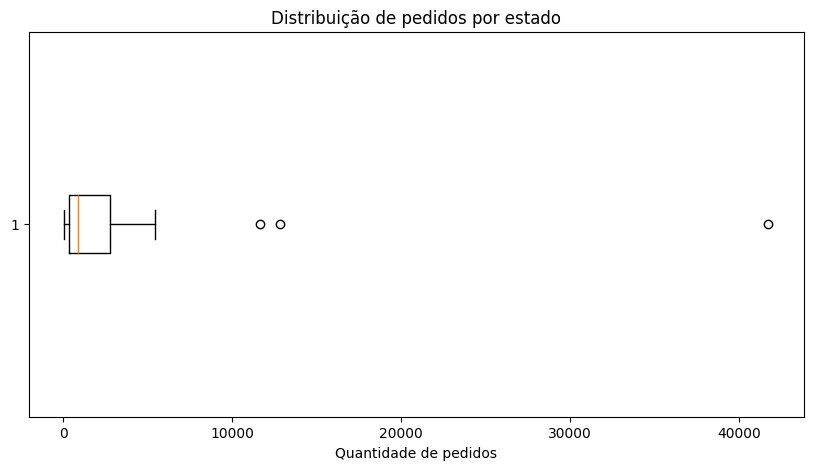

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.boxplot(
    pedidos_por_estado['total_pedidos'],
    vert=False
)

plt.xlabel('Quantidade de pedidos')
plt.title('Distribuição de pedidos por estado')

plt.show()

O gráfico boxplot prova que SP é um grande outlier do nosso Dataset, outros Estados como Rio de Janeiro e Minas Gerais também são outliers pois estão acima dos 10mil pedidos. Isso não significa que retiraremos esses Estados da análise, mas sim que precisaremos levar em consideração a diferença na concentração de pedidos nesses Estados.

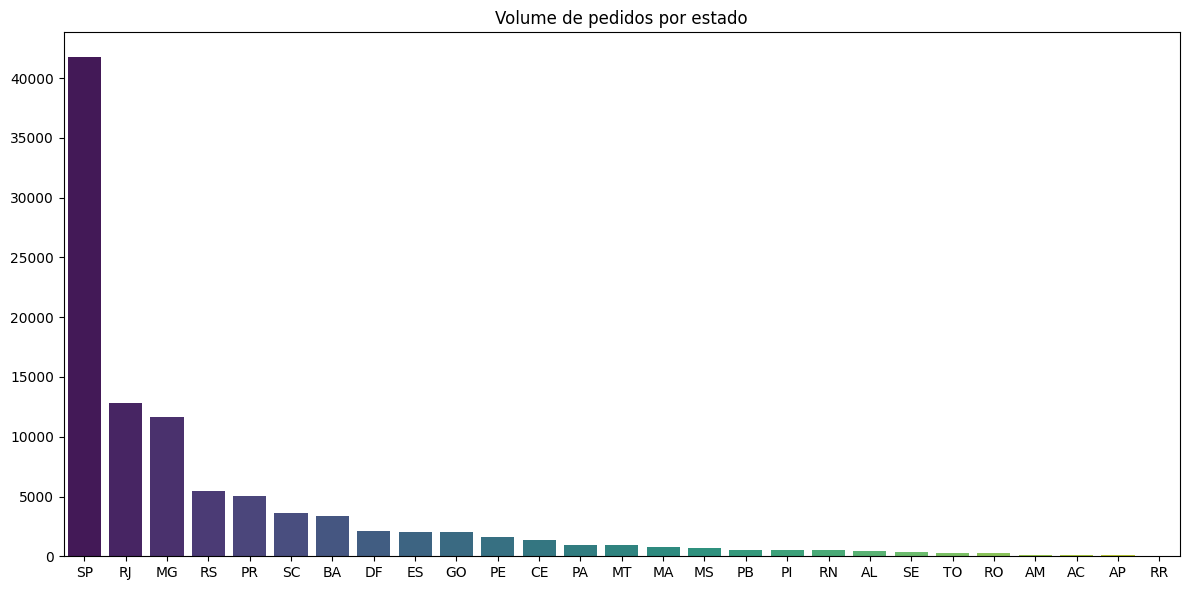

In [18]:
# Gerar um gráfico de barras para melhor visualização do volume de pedidos por Estado
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pedidos_por_estado,
    x='customer_state',
    y='total_pedidos',
    hue='customer_state',
    palette='viridis',
    legend=False
)

plt.xlabel('')
plt.ylabel('')
plt.title('Volume de pedidos por estado')

plt.tight_layout()
plt.show()

In [19]:
# Verificar o quantidade de pedidos em cada Estado por Ano
pedidos_estado_ano = (
    df_pedidos.groupby(['ano', 'customer_state'])['order_id']
      .nunique()
      .reset_index(name='quantidade_pedidos')
)

In [20]:
# Visualização do top 5 Estados com maior volume de pedidos
top5 = (
    df_pedidos.groupby('customer_state')['order_id']
      .nunique()
      .nlargest(5)
      .index
)



In [72]:
# Filtar os Estados que estão no top5
dados_top5 = pedidos_estado_ano[
    pedidos_estado_ano['customer_state'].isin(top5)
]

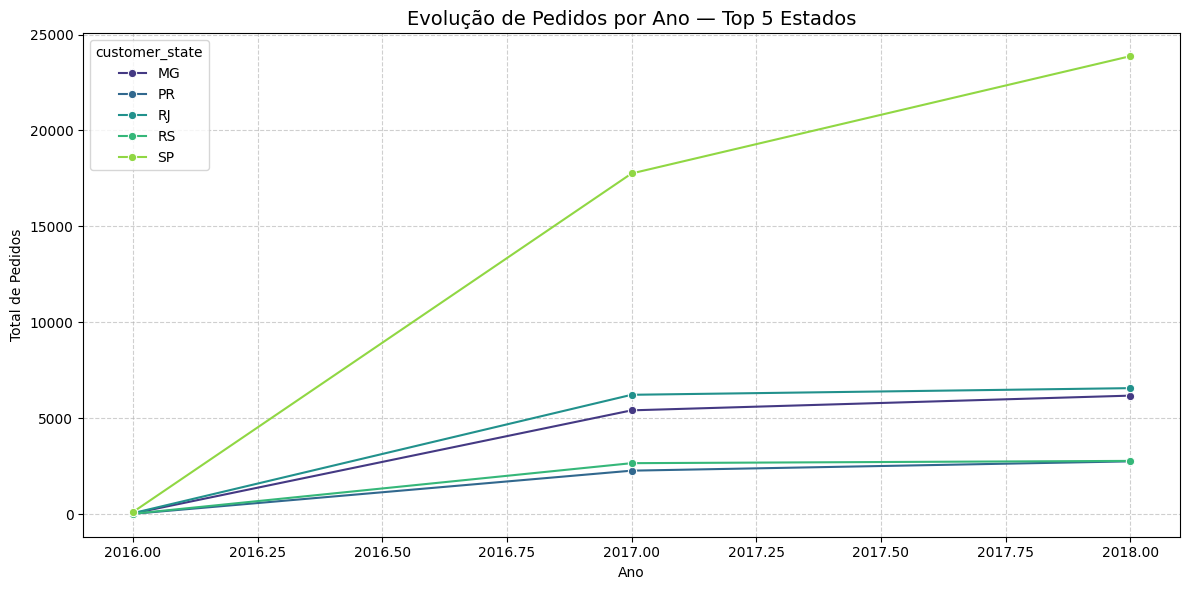

In [21]:
# Gráfico de linhas com a evolução de pedidos por ano dos top5 Estados
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=dados_top5,
    x='ano',
    y='quantidade_pedidos',
    hue='customer_state',
    palette='viridis',
    marker='o'
)

plt.title('Evolução de Pedidos por Ano — Top 5 Estados', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Total de Pedidos')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

De acordo com o gráfico de linhas onde mostra a evolução do número de pedidos por ano, nota-se que em SP os pedidos tiveram um grande crescimento e continuaram aumentando, enquando nos outros 4 Estados com maior número de pedidos após SP, os número crescem de 2016 a 2017 de depois se estabilizam no ano de 2017 a 2018.

In [22]:
# Verificar Receita por Estado considerando o preço do produto
receita_por_estado = (
    df_regional.groupby('customer_state')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index(name='receita_total')
)
receita_por_estado

,customer_state,receita_total
0,SP,5202955.05
1,RJ,1824092.67
2,MG,1585308.03
3,RS,750304.02
4,PR,683083.76
5,SC,520553.34
6,BA,511349.99
7,DF,302603.94
8,GO,294591.95
9,ES,275037.31


In [23]:
# Verificar ticket_medio por Estado considerando o preço do produto
ticket_medio = (
    df_regional.groupby('customer_state')['price']
    .mean()
    .sort_values(ascending=False)
)
ticket_medio

,price
customer_state,
PB,191.475216
AL,180.889212
AC,173.727717
RO,165.973525
PA,165.692417
AP,164.320732
PI,160.358081
TO,157.529333
RN,156.965936


In [24]:
# Calcular o impacto do frete em relação ao preço do produto
df_regional['frete_por_preco'] = df_regional['freight_value'] / df_regional['price']

frete_regional = df_regional.groupby('customer_state').agg(
    frete_medio=('freight_value', 'mean'),
    impacto_frete_pct=('frete_por_preco', lambda x: x.mean() * 100)
).sort_values(by='impacto_frete_pct', ascending=False)
frete_regional

,frete_medio,impacto_frete_pct
customer_state,,
RO,41.069712,59.418839
RR,42.984423,58.904955
MA,38.257002,54.932365
AC,40.073370,51.165056
PB,42.723804,51.159656
RN,35.652363,50.632980
PI,39.147970,49.984234
TO,37.246603,49.945929
AM,33.205394,49.813648


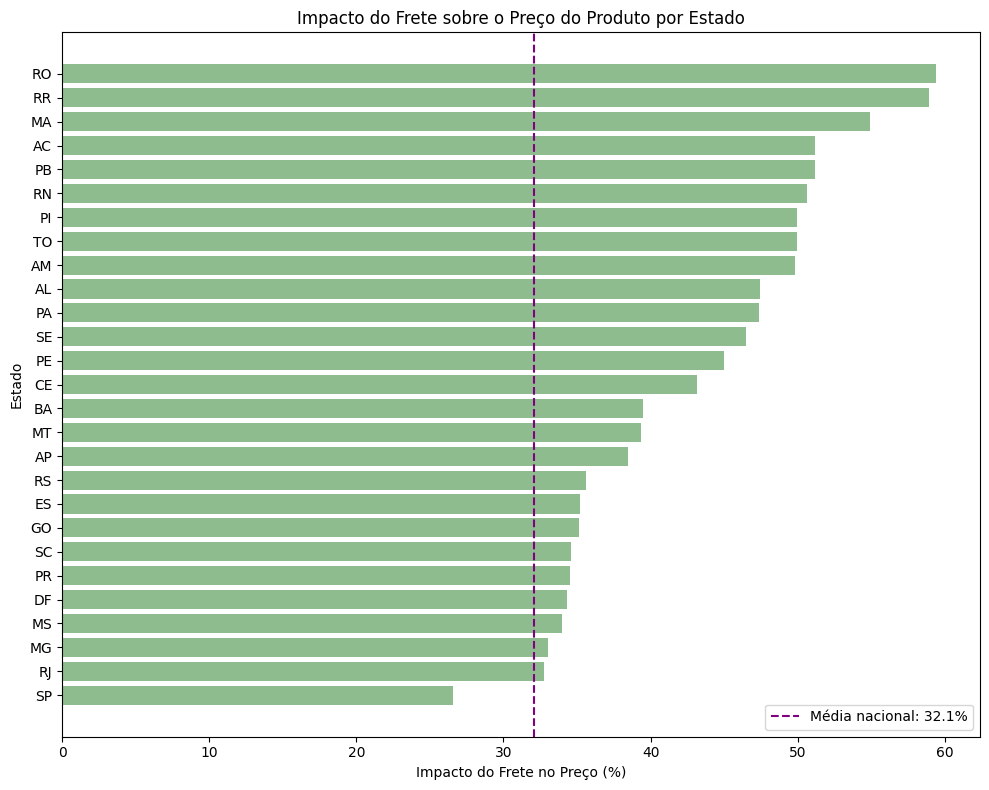

In [25]:
# Calcular a média nacional
media_nacional = df_regional['frete_por_preco'].mean() * 100

# Criar gráfico para melhor visualização dos dados
plt.figure(figsize=(10, 8))
plt.barh(frete_regional.index, frete_regional['impacto_frete_pct'], color='darkseagreen')
plt.axvline(media_nacional, color='purple', linestyle='--', linewidth=1.5,
            label=f'Média nacional: {media_nacional:.1f}%')
plt.xlabel('Impacto do Frete no Preço (%)')
plt.ylabel('Estado')
plt.title('Impacto do Frete sobre o Preço do Produto por Estado')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

No cálculo da Receita total por Estado SP, RJ e MG seguem no topo. Isso se deve ao volume de pedidos de cada um, por exemplo: SP tem 41.746 pedidos, então mesmo com ticket baixo por pedido, o total é enorme.

Na análise de ticket médio, os Estados no topo são PB, AL, AC, RO, PA, AP, e também, são justamente os que aparecem no fim da tabela de receita total.

Uma possível explicação sobre essa inversão de pódio seria com o cálculo do impacto do frete sobre o produto.

Por exemplo, em SP, como o frete é baixo (impacto de ~26%, o menor de todos), compras de qualquer valor, inclusive baixo, se tornam viáveis, o que explica o ticket médio mais baixo (R$109) combinado com o volume mais alto.

In [27]:
# Verificar proporção de vendedores por estado
df_regional['seller_state'].value_counts(normalize=True)

,proportion
seller_state,
SP,0.713200
MG,0.078358
PR,0.076973
RJ,0.042770
SC,0.036174
RS,0.019521
DF,0.007980
BA,0.005708
GO,0.004616


In [28]:
# Criar uma tabela de contingência para verificar a quantidade vendedores x quantidade de compradores por Estado
crosstab_pedidos = pd.crosstab(
    df_regional['seller_state'],
    df_regional['customer_state']
)

crosstab_pedidos

customer_state,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
seller_state,,,,,,,,,,,,,,,,,,,,,
AC,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
AM,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
BA,1,10,1,2,78,14,19,13,11,17,...,14,95,10,3,1,42,16,10,153,2
CE,0,2,1,0,3,9,1,3,1,2,...,6,10,1,1,0,1,2,3,26,0
DF,1,4,0,0,39,15,61,22,37,11,...,33,110,7,0,0,23,26,3,336,5
ES,0,0,0,0,30,4,1,9,3,2,...,16,74,2,1,0,21,14,1,119,4
GO,1,7,2,1,8,13,30,5,39,14,...,16,62,1,1,0,14,11,0,141,5
MA,1,4,1,1,10,9,28,13,17,15,...,9,42,3,0,0,17,20,6,131,2
MG,10,39,15,3,430,83,221,206,173,72,...,415,1329,35,16,4,315,288,41,2964,17


Text(50.722222222222214, 0.5, 'Vendedores')

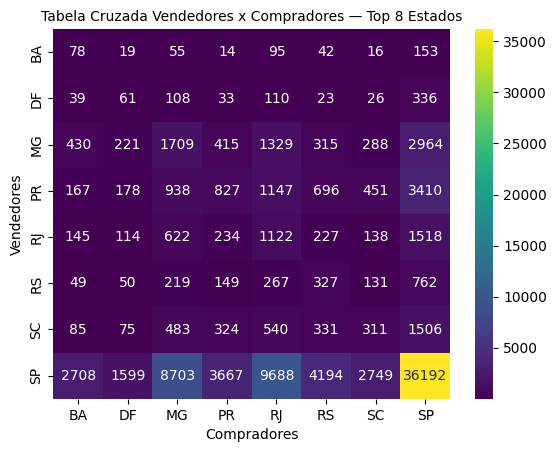

In [29]:
# Criar uma nova tabela de contigência com apenas os top 8 Estados para melhorar a visualização
top_sellers = df_regional['seller_state'].value_counts().head(8).index
top_customers = df_regional['customer_state'].value_counts().head(8).index

df_filtrado = df_regional[
    df_regional['seller_state'].isin(top_sellers) &
    df_regional['customer_state'].isin(top_customers)
]

crosstab_top = pd.crosstab(df_filtrado['seller_state'], df_filtrado['customer_state'])

# Criar um heatmap para melhor visualização da tabela
sns.heatmap(
    crosstab_top,
    cmap='viridis',
    annot=True,
    fmt='d')

plt.title('Tabela Cruzada Vendedores x Compradores — Top 8 Estados', fontsize=10)
plt.xlabel('Compradores')
plt.ylabel('Vendedores')


A distribuição geográfica dos vendedores também foi analisada com o objetivo de compreender a concentração da oferta dentro da plataforma. Para isso, foi calculada a participação relativa dos vendedores por estado. A análise revelou forte concentração dos vendedores em São Paulo, que representou aproximadamente 71,3% da base analisada.

Para investigar os fluxos comerciais entre regiões, foi construída uma tabela de contingência relacionando o estado do vendedor ao estado do cliente. Posteriormente, foi utilizada uma matriz de calor para facilitar a identificação visual das maiores concentrações de transações entre origem e destino.

Essa análise nos permite identificar possíveis razões para o desequilíbrio do número de demanda e oferta.

# 5- Construção do Painel Regional

Após a análise individual das métricas, foi construído um painel regional consolidado. As informações de volume de pedidos, receita total, taxa de atraso e impacto relativo do frete foram integradas utilizando customer_state como chave de relacionamento. A utilização de merge permitiu centralizar os principais indicadores em um único DataFrame, denominado painel_regional.

O painel consolidado passou a constituir a base para a etapa de construção dos indicadores compostos de potencial financeiro, saúde operacional e oportunidade regional.


In [30]:
# Filtrando apenas os produtos entregues
df_entregues = df_pedidos[df_pedidos['order_status'] == 'delivered'].copy()

In [31]:
# Criando uma tabela binária para pedidos atrasados
df_entregues['atrasado'] = (df_entregues['tempo_entrega_atraso'] > 0).astype(int)

In [32]:
# Calculando a taxa de atraso
taxa_atraso_estado = (
    df_entregues
    .groupby('customer_state')['atrasado']
    .mean()
    .mul(100)
    .reset_index(name='taxa_atraso')
)

In [33]:
# Verificando as taxas de atraso por valores do maior para o menor
taxa_atraso_estado.sort_values(by='taxa_atraso', ascending=False)

,customer_state,taxa_atraso
1,AL,23.173804
9,MA,18.828452
24,SE,15.223881
16,PI,15.126050
5,CE,14.933542
4,BA,13.329238
18,RJ,12.987854
26,TO,12.408759
13,PA,12.262156
21,RR,12.195122


In [34]:
# Adicionar a receita total por estado no novo df
painel_regional = pedidos_por_estado.copy()

painel_regional = painel_regional.merge(
    receita_por_estado,
    on='customer_state',
    how='left'
)


In [35]:
# Adicionar a taxa de atraso por estado no novo df
painel_regional = painel_regional.merge(
    taxa_atraso_estado,
    on='customer_state',
    how='left'
)

In [36]:
painel_regional.head()

,customer_state,total_pedidos,receita_total,taxa_atraso
0,SP,41746,5202955.05,5.439372
1,RJ,12852,1824092.67,12.987854
2,MG,11635,1585308.03,5.310904
3,RS,5466,750304.02,6.772685
4,PR,5045,683083.76,4.692261


In [37]:
frete_regional.head()

,frete_medio,impacto_frete_pct
customer_state,,
RO,41.069712,59.418839
RR,42.984423,58.904955
MA,38.257002,54.932365
AC,40.073370,51.165056
PB,42.723804,51.159656


In [38]:
# Adicionar o Estado e o impacto do frete no novo df
frete_regional = frete_regional.reset_index()

painel_regional = painel_regional.merge(
    frete_regional[['customer_state', 'impacto_frete_pct']],
    on='customer_state',
    how='left'
)

In [39]:
# Visualizar colunas finais
painel_regional.columns.tolist()

['customer_state',
 'total_pedidos',
 'receita_total',
 'taxa_atraso',
 'impacto_frete_pct']

# 6- Construção dos Indicadores (Financeiro, Operacional e de Oportunidade)

Objetivo:

Normalização dos dados;

Criação do indicador de potencial de receita;

Criação do indicador de saúde operacional (logística);

Criação do indicador de Oportunidade;

Criação da Matriz de Oportunidade.

In [40]:
# Normalizar os dados e criar novas colunas com os scores
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

painel_regional[
    ['score_pedidos',
     'score_receita',
     'score_atraso',
     'score_frete']
] = scaler.fit_transform(
    painel_regional[
        ['total_pedidos',
         'receita_total',
         'taxa_atraso',
         'impacto_frete_pct']
    ]
) * 100

In [41]:
# Inverter os valores max e min das variáveis atraso e frete
painel_regional['score_atraso'] = (
    100 - painel_regional['score_atraso']
)

painel_regional['score_frete'] = (
    100 - painel_regional['score_frete']
)

In [42]:
painel_regional.head()

,customer_state,total_pedidos,receita_total,taxa_atraso,impacto_frete_pct,score_pedidos,score_receita,score_atraso,score_frete
0,SP,41746,5202955.05,5.439372,26.540670,100.000000,100.000000,87.391243,100.000000
1,RJ,12852,1824092.67,12.987854,32.727232,30.709832,34.960911,50.194040,81.183375
2,MG,11635,1585308.03,5.310904,33.042761,27.791367,30.364590,88.024305,80.223685
3,RS,5466,750304.02,6.772685,35.578698,12.997602,14.291754,80.820980,72.510550
4,PR,5045,683083.76,4.692261,34.495562,11.988010,12.997844,91.072836,75.804945


In [43]:
# Criar o score financeiro
painel_regional['score_financeiro'] = (
    painel_regional['score_receita'] * 0.60 +
    painel_regional['score_pedidos'] * 0.40
)

In [44]:
# Criar o score operacional
painel_regional['score_operacional'] = (
    painel_regional['score_atraso'] * 0.60 +
    painel_regional['score_frete'] * 0.40
)

In [45]:
# Criar o score de oportunidade
painel_regional['score_oportunidade'] = (
    painel_regional['score_financeiro'] * 0.60 +
    painel_regional['score_operacional'] * 0.40
)

In [46]:
painel_regional.head()

,customer_state,total_pedidos,receita_total,taxa_atraso,impacto_frete_pct,score_pedidos,score_receita,score_atraso,score_frete,score_financeiro,score_operacional,score_oportunidade
0,SP,41746,5202955.05,5.439372,26.540670,100.000000,100.000000,87.391243,100.000000,100.000000,92.434746,96.973898
1,RJ,12852,1824092.67,12.987854,32.727232,30.709832,34.960911,50.194040,81.183375,33.260479,62.589774,44.992197
2,MG,11635,1585308.03,5.310904,33.042761,27.791367,30.364590,88.024305,80.223685,29.335301,84.904057,51.562803
3,RS,5466,750304.02,6.772685,35.578698,12.997602,14.291754,80.820980,72.510550,13.774093,77.496808,39.263179
4,PR,5045,683083.76,4.692261,34.495562,11.988010,12.997844,91.072836,75.804945,12.593910,84.965680,41.542618


In [47]:
painel_regional[
    [
        'customer_state',
        'score_financeiro',
        'score_operacional',
        'score_oportunidade'
    ]
].sort_values(
    'score_oportunidade',
    ascending=False
)

,customer_state,score_financeiro,score_operacional,score_oportunidade
0,SP,100.000000,92.434746,96.973898
2,MG,29.335301,84.904057,51.562803
1,RJ,33.260479,62.589774,44.992197
4,PR,12.593910,84.965680,41.542618
3,RS,13.774093,77.496808,39.263179
7,DF,5.413069,79.166173,34.914310
25,AP,0.086297,85.202334,34.132712
5,SC,9.366200,70.692543,33.896737
9,GO,5.205428,75.366931,33.270029
13,MT,2.542402,74.284588,31.239276


Como os indicadores utilizados, no painel_regional apresentam escalas distintas,foi realizada uma normalização das variáveis utilizando o método MinMaxScaler, disponibilizado pela biblioteca Scikit-learn. Os valores foram transformados para uma escala de 0 a 100, permitindo a comparação e combinação das diferentes métricas.

Para os indicadores em que valores menores representam melhor desempenho, especificamente taxa de atraso e impacto do frete, a escala foi posteriormente invertida. Dessa forma, valores maiores passaram a representar melhores condições operacionais.

O Score Financeiro foi construído a partir da combinação dos indicadores de receita e volume de pedidos. Foi atribuído peso de 60% à receita e 40% ao volume de pedidos, considerando que a receita representa diretamente o valor econômico gerado, enquanto o volume de pedidos representa a dimensão da demanda.

O Score Operacional foi construído combinando o desempenho relacionado aos atrasos e o impacto relativo do frete. Foi atribuído peso de 60% ao indicador de atraso e 40% ao indicador de frete, considerando a relevância do cumprimento dos prazos para a eficiência logística e experiência do consumidor.

Por fim, foi criado um Score de Oportunidade com o objetivo de sintetizar o potencial financeiro e a condição operacional de cada estado. O indicador atribuiu peso de 60% ao Score Financeiro e 40% ao Score Operacional.

In [48]:
# Calculando a mediana dos scores para classificação de oportunidade
mediana_financeiro = painel_regional['score_financeiro'].median()

mediana_operacional = painel_regional['score_operacional'].median()

print('Mediana financeira:', mediana_financeiro)
print('Mediana operacional:', mediana_operacional)

Mediana financeira: 2.54240175852717
Mediana operacional: 62.234232303807694


Para a classificação de oportunidade na Matriz vamos considerar os valores Score:

Financeiro >= 2.5 → alto

Financeiro < 2.5 → baixo

e

Operacional >= 62 → alto

Operacional < 62 → baixo

In [49]:
# Criar função para classificar os Estados de acordo com as medianas do score calculado

def classificar_estado(row):

    if (
        row['score_financeiro'] >= mediana_financeiro
        and row['score_operacional'] >= mediana_operacional
    ):
        return 'Oportunidade de Expansão'

    elif (
        row['score_financeiro'] >= mediana_financeiro
        and row['score_operacional'] < mediana_operacional
    ):
        return 'Corrigir operacional antes de expandir'

    elif (
        row['score_financeiro'] < mediana_financeiro
        and row['score_operacional'] >= mediana_operacional
    ):
        return 'Desenvolver'

    else:
        return 'Monitorar'

In [50]:
# Criar a coluna de prioridade para a classificação dos Estados
painel_regional['prioridade'] = (
    painel_regional.apply(classificar_estado, axis=1)
)

In [51]:
# Visualizar a tabela de acordo com a maior Prioridade
painel_regional[
    [
        'customer_state',
        'score_financeiro',
        'score_operacional',
        'score_oportunidade',
        'prioridade'
    ]
].sort_values(
    'score_oportunidade',
    ascending=False
)

,customer_state,score_financeiro,score_operacional,score_oportunidade,prioridade
0,SP,100.000000,92.434746,96.973898,Oportunidade de Expansão
2,MG,29.335301,84.904057,51.562803,Oportunidade de Expansão
1,RJ,33.260479,62.589774,44.992197,Oportunidade de Expansão
4,PR,12.593910,84.965680,41.542618,Oportunidade de Expansão
3,RS,13.774093,77.496808,39.263179,Oportunidade de Expansão
7,DF,5.413069,79.166173,34.914310,Oportunidade de Expansão
25,AP,0.086297,85.202334,34.132712,Desenvolver
5,SC,9.366200,70.692543,33.896737,Oportunidade de Expansão
9,GO,5.205428,75.366931,33.270029,Oportunidade de Expansão
13,MT,2.542402,74.284588,31.239276,Oportunidade de Expansão


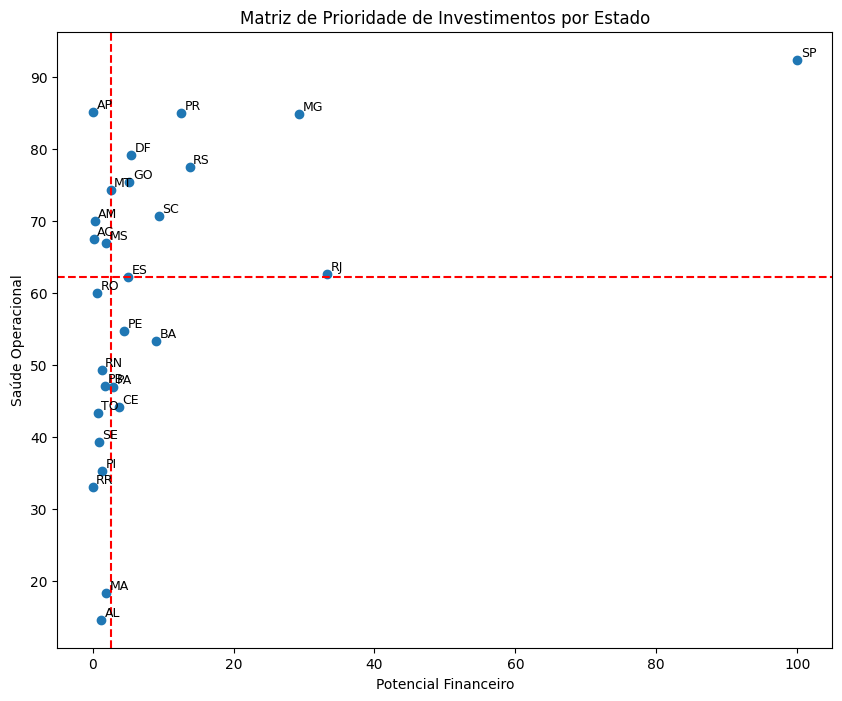

In [52]:
# Criar um gráfico de dispersão para melhor visualização da matriz de oportunidade
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    painel_regional['score_financeiro'],
    painel_regional['score_operacional']
)

for i, row in painel_regional.iterrows():
    plt.text(
        row['score_financeiro'] + 0.5,
        row['score_operacional'] + 0.5,
        row['customer_state'],
        fontsize=9
    )

plt.axvline(
    mediana_financeiro,
    linestyle='--',
    color='red'
)

plt.axhline(
    mediana_operacional,
    linestyle='--',
    color='red'
)

plt.xlabel('Potencial Financeiro')
plt.ylabel('Saúde Operacional')
plt.title('Matriz de Prioridade de Investimentos por Estado')

plt.show()

Visão Geral

A análise mostra que São Paulo mantém liderança tanto em potencial econômico quanto em eficiência operacional, mostrando grande oportunidade de expansão. Estados como Minas Gerais, Rio Grande do Sul, Distrito Federal, Goiás, Santa Catarina e Paraná apresentam boa saúde logística e podem representar oportunidades de expansão, mesmo com potencial financeiro menor que São Paulo porém ainda maiores que a nota de corte. Já regiões com alto potencial, mas operação mais frágil, exigem investimentos logísticos antes de acelerar o crescimento.

Oportunidade de Expansão

Além de São Paulo, MG, RJ, PR, RS, DF, SC, GO, MT, ES aparecem como "Oportunidade de Expansão" mesmo com score financeiro baixo (5 a 33), porque o score operacional deles já é bom (62 a 92).

Como a infraestrutura logística já funciona bem nesses estados, pode ser que o volume de negócio ainda seja pequeno perto do potencial. Isso pode indicar uma oportunidade de investimento de baixo risco operacional, já que a logística funciona bem, podendo focar apenas no investimento comercial, como marketing, parcerias ou companhas com vendedores locais, por exemplo.

Corrigir operacional antes de expandir

Já BA, PE, PA, CE estão nessa categoria pois possuem score financeiro relativamente mais alto que a média, indicando que já existe alguma demanda real, mas score operacional baixo (44-54), ou seja, a demanda existe, mas a logística está falhando. Investir em expandir comercialmente aqui sem antes resolver a operação poderia ter um alto risco pois a taxa de atraso e o impacto do frete poderia impactar diretamente na demanda e prejudicar a experiência do cliente.

Desenvolver

AP, AM, MS, AC têm financeiro quase zero e operacional mediano,mercado sem sinal forte nem de demanda nem de problema logístico grave. Precisam de desenvolvimento de mercado antes de qualquer coisa.

Monitorar

O grupo grande formado por RN, PB, TO, SE, PI, RR, MA, AL, e RO tem os dois scores baixos, nem demanda relevante, nem operação boa. Não são prioridade imediata, mas não devem ser descartados apenas acompanhados.